In [1]:
#!pip install nsepy

In [3]:
from Descriptive import Descriptive

In [5]:
obj=Descriptive()

In [7]:
import pandas as pd
stk_data=pd.read_csv("Tatacoffee13_21.csv")

In [9]:
stk_data["Date"]=pd.to_datetime(stk_data["Date"])
stk_data.set_index("Date",inplace=True)

In [11]:
stk_data.head()

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65


In [13]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2225 entries, 2013-01-01 to 2021-12-28
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2225 non-null   float64
 1   High    2225 non-null   float64
 2   Low     2225 non-null   float64
 3   Close   2225 non-null   float64
dtypes: float64(4)
memory usage: 86.9 KB


In [15]:
stk_data

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2021-12-22,202.90,207.80,201.35,205.00
2021-12-23,206.00,206.85,202.05,202.95
2021-12-24,203.90,203.90,199.35,201.00


In [17]:
low=stk_data["Low"]

In [19]:
dataset=stk_data
quan,qual=obj.segreQuanQual(dataset)

The Quantitative Data: ['Open', 'High', 'Low', 'Close']
The Qualtitative Data []


In [21]:
des_data=obj.descriptive_Analysis(dataset,quan)

D:\AI course\AI\Time Series Analysis\1.TS-EDA\Descriptive.py:24: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  des_data[i]["Null_count"]=dataset[i].isnull().sum()
D:\AI course\AI\Time Series Analysis\1.TS-EDA\Descriptive.py:25: FutureWarning

In [23]:
des_data

,Open,High,Low,Close
Null_count,0,0,0,0
NonNull_count,2225,2225,2225,2225
Total_Count,2225,2225,2225,2225
Mean,340.559393,346.094337,335.565528,339.695663
Median,118.85,121.4,116.7,118.65
Mode,91.0,93.0,91.0,90.75
Std,430.215976,436.921149,424.348805,429.059366
Min,49.4,50.9,48.0,49.4
Q1:25%,92.6,94.0,91.35,92.3
Q2:50%,118.85,121.4,116.7,118.65


In [25]:
des_data["Low"]

Null_count                0
NonNull_count          2225
Total_Count            2225
Mean             335.565528
Median                116.7
Mode                   91.0
Std              424.348805
Min                    48.0
Q1:25%                91.35
Q2:50%                116.7
Q3:75%               207.95
Q4:100%             1636.95
IQR                   116.6
1.5Rule               174.9
Lesser               -83.55
Greater              382.85
Name: Low, dtype: object

In [27]:
des_data["High"]

Null_count                0
NonNull_count          2225
Total_Count            2225
Mean             346.094337
Median                121.4
Mode                   93.0
Std              436.921149
Min                    50.9
Q1:25%                 94.0
Q2:50%                121.4
Q3:75%                215.0
Q4:100%              1679.7
IQR                   121.0
1.5Rule               181.5
Lesser                -87.5
Greater               396.5
Name: High, dtype: object

In [29]:
import numpy as np
np.percentile(dataset["Low"],99)

np.float64(1565.1399999999996)

In [31]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # generate a sample
    sample = dataset
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std)
    
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]    
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob
    

Mean=335.566, Standard Deviation=424.349
The area between range(50,200):0.12412467157336267


C:\Users\User\AppData\Local\Temp\ipykernel_25428\2842244316.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


np.float64(0.12412467157336267)

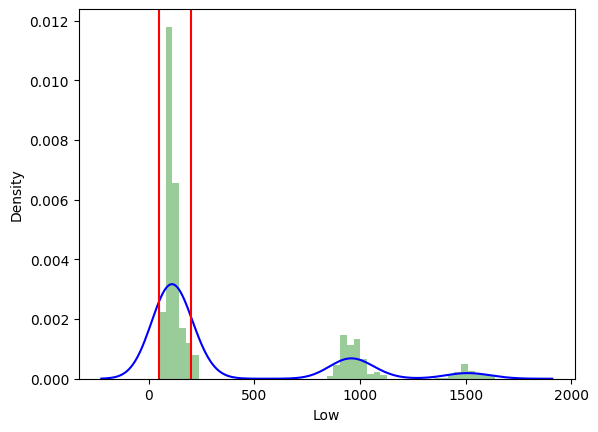

In [33]:
 get_pdf_probability(dataset["Low"],50,200)

In [34]:
def stdNBgraph(dataset):
        # Coverted to standard Normal Distribution
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()

    values=[i for i in dataset]

    z_score=[((j-mean)/std) for j in values]

    sns.distplot(z_score,kde=True)

    sum(z_score)/len(z_score)
    #z_score.std()

C:\Users\User\AppData\Local\Temp\ipykernel_25428\4109782476.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True)


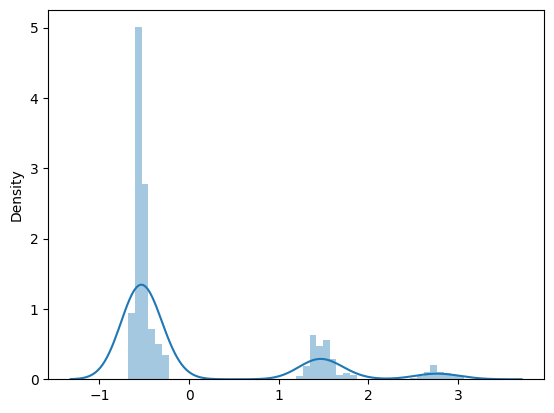

In [37]:
stdNBgraph(dataset["Low"])

In [39]:
def freqTable(columnName,dataset):
    import pandas as pd
    frq=pd.DataFrame()
    frq["Unique_Values"]=dataset[columnName].value_counts().index
    frq["Frequency"]=dataset[columnName].value_counts().values
    frq["Relative_Fre"]=dataset[columnName].value_counts().values/len(dataset[columnName])*100
    frq["Cumulative"]=frq["Relative_Fre"].cumsum()
    return frq

In [41]:
freqTable("Low",dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,91.00,10,0.449438,0.449438
1,87.50,9,0.404494,0.853933
2,90.10,9,0.404494,1.258427
3,86.50,9,0.404494,1.662921
4,89.10,8,0.359551,2.022472
...,...,...,...,...
1435,90.95,1,0.044944,99.820225
1436,85.20,1,0.044944,99.865169
1437,85.95,1,0.044944,99.910112
1438,86.60,1,0.044944,99.955056


In [43]:
fh=freqTable("High",dataset)
fh

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,93.00,11,0.494382,0.494382
1,113.40,9,0.404494,0.898876
2,95.40,9,0.404494,1.303371
3,91.80,9,0.404494,1.707865
4,90.50,7,0.314607,2.022472
...,...,...,...,...
1452,87.45,1,0.044944,99.820225
1453,94.10,1,0.044944,99.865169
1454,90.15,1,0.044944,99.910112
1455,88.35,1,0.044944,99.955056


In [45]:
fh.sort_values(by="Frequency",ascending=False)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,93.00,11,0.494382,0.494382
2,95.40,9,0.404494,1.303371
3,91.80,9,0.404494,1.707865
1,113.40,9,0.404494,0.898876
4,90.50,7,0.314607,2.022472
...,...,...,...,...
780,129.15,1,0.044944,69.617978
781,95.30,1,0.044944,69.662921
782,126.75,1,0.044944,69.707865
783,93.10,1,0.044944,69.752809


In [73]:
fhs=fh[fh["Frequency"]==9]["Unique_Values"].sort_values(ascending=False)
fhs

1    113.4
2     95.4
3     91.8
Name: Unique_Values, dtype: float64